In [1]:
import requests

currencies = {
    'USD' : 1,
    'GBP' : 2,
    'EUR' : 3,
    'CHF' : 4,
    'RUB' : 5,
    'KRW' : 16,
    'CAD' : 20,
}

appid = '730'
country = 'SE'
currency = 3
steamLoginSecure = ''

url = 'http://steamcommunity.com/market/pricehistory'


In [2]:

"""

Navaja, Talon, Ursus, Stiletto

"""

assets = [
    'Prisma Case', 'Prisma 2 Case', 'Horizon Case', 'Clutch Case',
    'Danger Zone Case',
]


In [3]:
data = {}

for asset in assets:
    url = 'http://steamcommunity.com/market/pricehistory'
    history = requests.get(
        url, 
        params={
        'appid': appid,
        'market_hash_name': asset,
        'country': country,
        'currency': currency,
      },
        cookies={
            'steamLoginSecure': steamLoginSecure,
        }
    )
    data[asset] = history.json()['prices']
    

In [4]:
import numpy as np
dataset = {}
for asset in assets:
    dataset[asset] = {}
    dataset[asset]['price'] = np.array([p[1] for p in data[asset]])
    dataset[asset]['time'] = np.array([p[0].split(':')[0] for p in data[asset]])
    

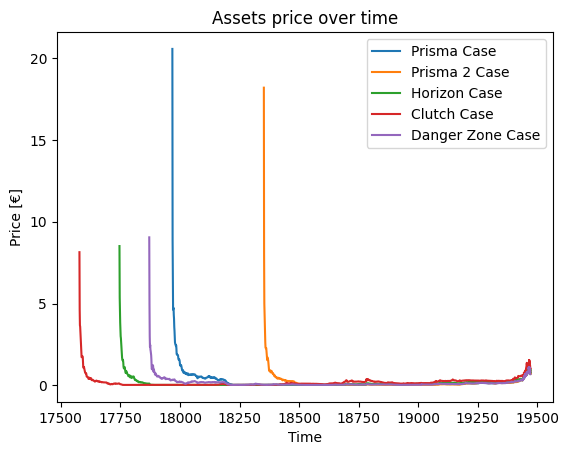

In [5]:
from datetime import datetime
import matplotlib.dates
import calendar
import matplotlib.pyplot as plt

m2n = {m: i for i, m in enumerate(calendar.month_abbr)}
del[m2n['']]

for asset in assets:
    dates = []
    for t in dataset[asset]['time']:
        month, day, year, time = t.split(' ')
        dtime = datetime(int(year), m2n[month], int(day), int(time))
        dates.append(dtime)
    plt.plot(matplotlib.dates.date2num(dates), dataset[asset]['price'], label=asset)

plt.title('Assets price over time')
plt.ylabel('Price [€]')
plt.xlabel('Time')
plt.legend(loc='best')
plt.show()


In [6]:
quantity = {}
quantity['Clutch Case'] = 119437
quantity['Danger Zone Case'] = 183661
quantity['Prisma 2 Case'] = 108733
quantity['Prisma Case'] = 101701
quantity['Horizon Case'] = 58031


Prisma Case: 6.784594055122368e-06
Prisma 2 Case: 6.667708975196123e-06
Horizon Case: 1.333769881614999e-05
Clutch Case: 8.464713614709009e-06
Danger Zone Case: 3.7678113480815195e-06


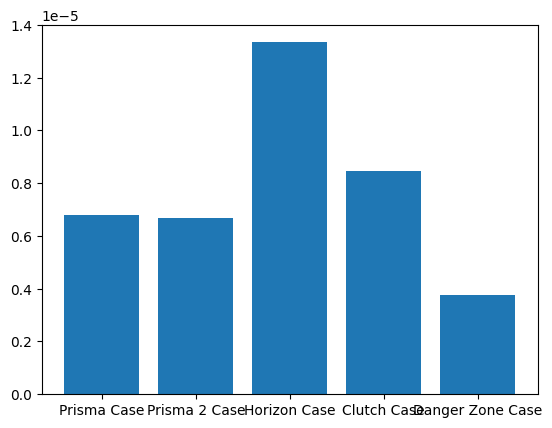

In [7]:
qp = []
for asset in assets:
    q = quantity[asset]
    p = dataset[asset]['price'][-1]
    print(f'{asset}: {p/q}')
    qp.append(p/q)
    
plt.bar(assets, qp)
plt.show()
    

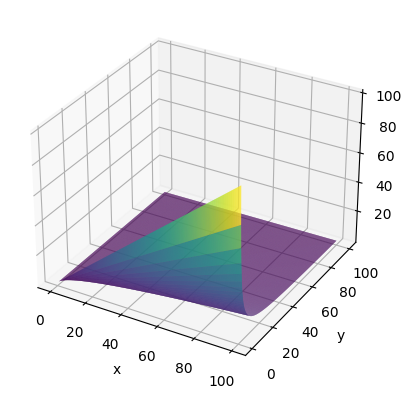

In [8]:
p = np.linspace(0.03, 100, num=300)
q = np.linspace(1, 100, num=300)
x, y = np.meshgrid(p, q)

z = x / y

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='viridis', rstride=1, cstride=1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()


In [9]:
opened = {}
opened['Clutch Case'] = 4263675
opened['Horizon Case'] = 752136
opened['Danger Zone Case'] = 1610281
opened['Prisma Case'] = 1076868
opened['Prisma 2 Case'] = 2180436


In [10]:
"""

Opened, o
Quantity, q
Price, p

många öppnar lådan -> metric bli stor

o / q

"""

'\n\nOpened, o\nQuantity, q\nPrice, p\n\nmånga öppnar lådan -> metric bli stor\n\no / q\n\n'

Prisma Case: 10.58856845065437
Prisma 2 Case: 20.05312094764239
Horizon Case: 12.960934672847271
Clutch Case: 35.69810862630508
Danger Zone Case: 8.767680672543436


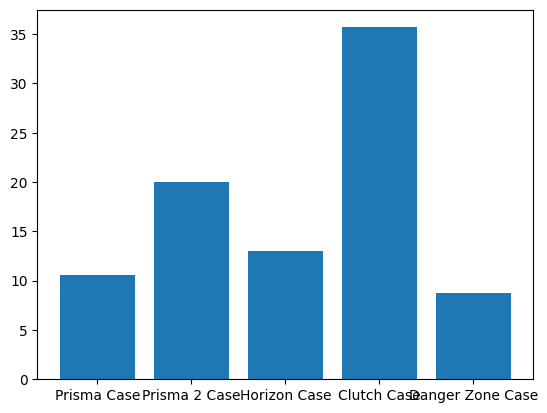

In [11]:
oq = []
for asset in assets:
    q = quantity[asset]
    o = opened[asset]
    print(f'{asset}: {o/q}')
    oq.append(o/q)
    
plt.bar(assets, oq)
plt.show()


Prisma Case: 15.345751377759958
Prisma 2 Case: 27.659477169161917
Horizon Case: 16.745393634169602
Clutch Case: 35.30970190534627
Danger Zone Case: 12.670058775351787


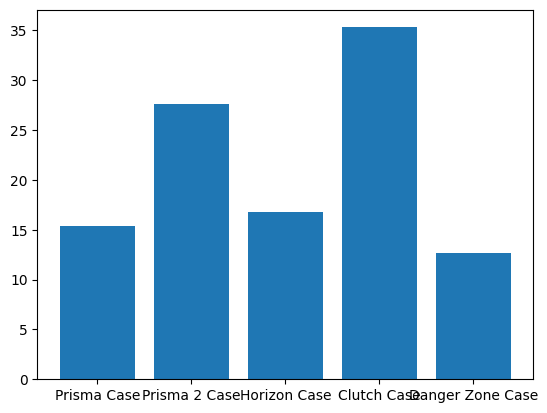

In [12]:
opq = []
for asset in assets:
    q = quantity[asset]
    o = opened[asset]
    p = dataset[asset]['price'][-1]
    print(f'{asset}: {o/(p*q)}')
    opq.append(o/(p*q))
    
plt.bar(assets, opq)
plt.show()
